Parameter bounds (mean ± 2*std):
  A_am: [0.0870, 0.1190] (mean=0.1030)
  B_am: [30.9000, 47.3000] (mean=39.1000)
  C_am: [2.0000, 10.0000] (mean=6.0000)
  A_bm: [0.0000, 0.2800] (mean=0.1200)
  D_bm: [7.5000, 24.3000] (mean=15.9000)
  A_ah: [0.0016, 0.0072] (mean=0.0044)
  D_ah: [17.9000, 26.3000] (mean=22.1000)
  E_bh: [0.7600, 1.1600] (mean=0.9600)
  F_bh: [23.4000, 46.2000] (mean=34.8000)
  G_bh: [2.4000, 21.2000] (mean=11.8000)

Generating 4096 Saltelli samples...
Sampling completed in 0.25 seconds
Total parameter sets to simulate: 90112

Running 90112 simulations...


/var/folders/nw/qqw2xvy17fv7cxtzjlhg366r0000gn/T/ipykernel_40148/2407244984.py:148: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, N, calc_second_order=True)


Simulations completed in 4.77 minutes
Valid simulations: 90112/90112 (100.0%)
Failed simulations: 0/90112 (0.0%)
Slow simulations (>0.5s): 0

Post-processing simulation results...
Replaced 0 failed simulations with population mean

Computing Sobol indices...
  Processing time point 0/1001


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


  Processing time point 200/1001
  Processing time point 400/1001
  Processing time point 600/1001
  Processing time point 800/1001
  Processing time point 1000/1001
Sobol analysis completed in 483.30 seconds

Generating plots...


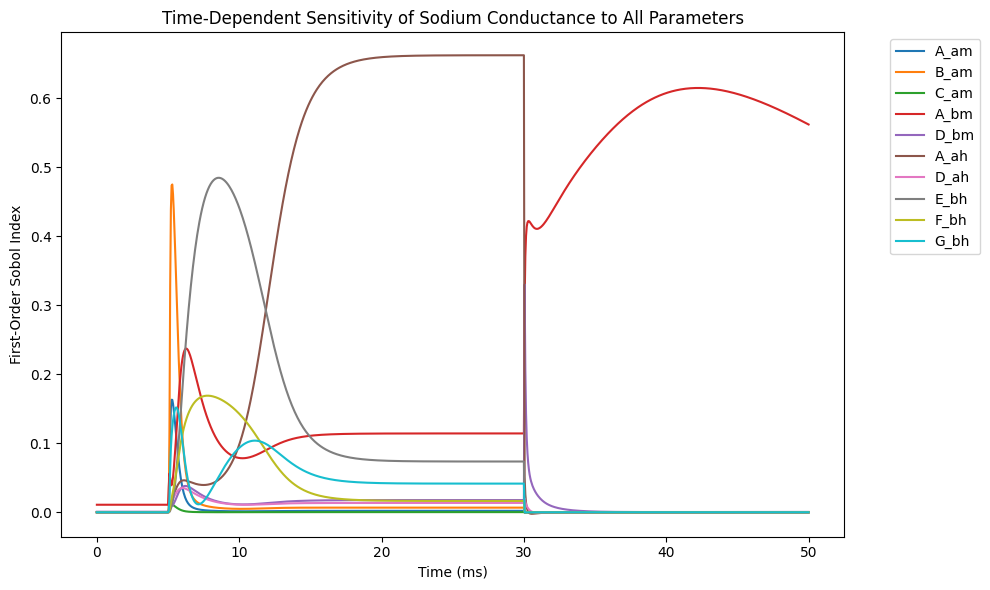

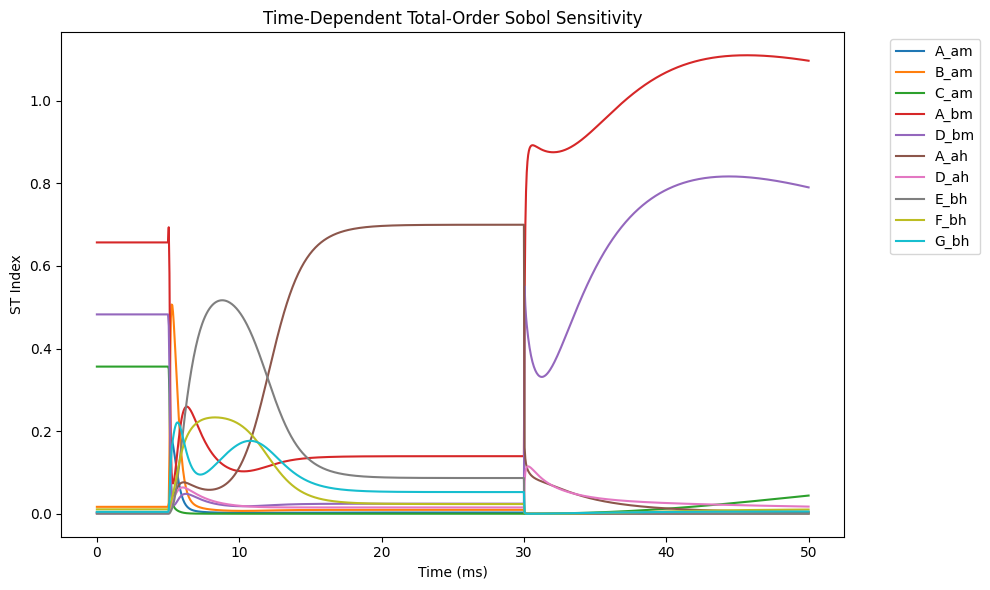

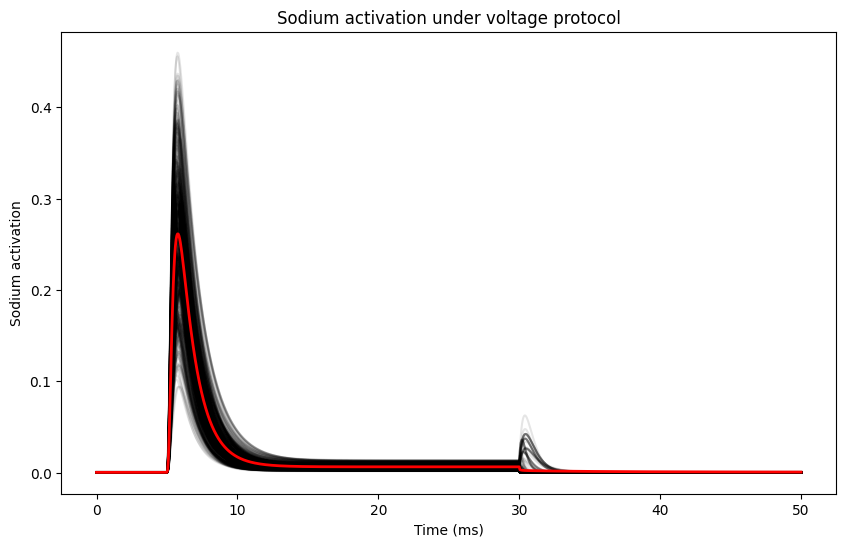

Saving results...
  Saved 500 valid conductance traces to all_g_na.csv
  Saved Sobol indices and mean conductance

Total execution time: 12.84 minutes


In [22]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import warnings
import time

# SALib imports
from SALib.sample import saltelli
from SALib.analyze import sobol

def simulate_Na_conductance(params, t_steps, v_steps, tmax=50.0, dt=0.05):
    """
    Simulate the sodium conductance under a given voltage protocol with parameterized gating functions.
    
    Parameters
    ----------
    params : list or array
        Parameter vector [A_am, B_am, C_am, A_bm, D_bm, A_ah, D_ah, E_bh, F_bh, G_bh]
    t_steps : list or array
        Times defining the voltage step protocol
    v_steps : list or array
        Voltages at each step
    tmax : float
        Total simulation time in ms.
    dt : float
        Time step for integration in ms.
    
    Returns
    -------
    time : numpy array
        The time vector for the simulation.
    g_trace : numpy array
        The sodium conductance at each time step.
    """
    # Unpack parameters
    A_am, B_am, C_am, A_bm, D_bm, A_ah, D_ah, E_bh, F_bh, G_bh = params
    
    # Validate parameters to avoid numerical issues
    if A_am <= 0 or C_am <= 0 or A_bm <= 0 or D_bm <= 0 or A_ah <= 0 or D_ah <= 0 or E_bh <= 0 or G_bh <= 0:
        time = np.arange(0, tmax+dt, dt)
        return time, np.full_like(time, np.nan)

    # Parameterized gating functions
    def alpha_m(V):
        val = (V + B_am) / C_am
        if abs(val) < 1e-6:
            return A_am
        else:
            return A_am * (V + B_am) / (1.0 - np.exp(-val))
    
    def beta_m(V):
        return A_bm * np.exp(-V/D_bm)
    
    def alpha_h(V):
        return A_ah * np.exp(-V/D_ah)
    
    def beta_h(V):
        return E_bh / (1.0 + np.exp(-(V+F_bh)/G_bh))
    
    def VC(ti, t, v):
        # Piecewise voltage command
        return (v[0]*(ti >= t[0]) +
                (v[1]-v[0])*(ti >= t[1]) +
                (v[2]-v[1])*(ti >= t[2]))
    
    def dmdh_dt(Y, ti):
        m, h = Y
        V = VC(ti, t_steps, v_steps)
        dm = alpha_m(V)*(1.0 - m) - beta_m(V)*m
        dh = alpha_h(V)*(1.0 - h) - beta_h(V)*h
        return [dm, dh]

    # Time vector
    time = np.arange(0, tmax+dt, dt)

    try:
        # Initial conditions for m and h (steady state at initial holding voltage)
        V_hold = VC(0, t_steps, v_steps)
        am_init = alpha_m(V_hold)
        bm_init = beta_m(V_hold)
        ah_init = alpha_h(V_hold)
        bh_init = beta_h(V_hold)
        
        m_inf_init = am_init / (am_init + bm_init)
        h_inf_init = ah_init / (ah_init + bh_init)
        Y0 = [m_inf_init, h_inf_init]

        # Solve the ODE system with warnings suppressed
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            solution = odeint(dmdh_dt, Y0, time)
        
        m_trace = solution[:, 0]
        h_trace = solution[:, 1]

        # Compute conductance: g_Na(t) = m^3 * h
        g_trace = (m_trace**3) * h_trace
        
        # Check for invalid values
        if np.any(np.isnan(g_trace)) or np.any(np.isinf(g_trace)):
            return time, np.full_like(time, np.nan)
        
        # Clip to reasonable range
        g_trace = np.clip(g_trace, 0, 1)
        
        return time, g_trace
    except:
        return time, np.full_like(time, np.nan)


if __name__ == "__main__":
    start_time = time.time()
    
    # Voltage protocol
    t_steps = [0.0, 5.0, 30.0]
    v_steps = [-80.0, -10.0, -80.0]

    # Base (reference) parameters for the gating (from the original HH model)
    base_params = np.array([0.103, 39.1, 6.0,
                            0.12, 15.9,
                            0.0044, 22.1,
                            0.96, 34.8, 11.8])
    
    # Standard deviations
    std = np.array([0.008, 4.1, 2, 0.08, 4.2, 0.0014, 2.1, 0.1, 5.7, 4.7])
    
    # Define parameter ranges as mean ± 2*std (uniform distribution)
    low = base_params - 2*std
    low = np.maximum(low, 1e-10)  # Ensure no negative values
    high = base_params + 2*std
    
    print("Parameter bounds (mean ± 2*std):")
    param_names = ['A_am', 'B_am', 'C_am', 'A_bm', 'D_bm', 'A_ah', 'D_ah', 'E_bh', 'F_bh', 'G_bh']
    for i, name in enumerate(param_names):
        print(f"  {name}: [{low[i]:.4f}, {high[i]:.4f}] (mean={base_params[i]:.4f})")

    # Set up the problem dictionary for SALib
    problem = {
        'num_vars': 10,
        'names': param_names,
        'bounds': list(zip(low, high))
    }

    # Generate samples using Saltelli (uniform distribution)
    N =  4096
    print(f"\nGenerating {N} Saltelli samples...")
    sample_start = time.time()
    param_values = saltelli.sample(problem, N, calc_second_order=True)
    print(f"Sampling completed in {time.time() - sample_start:.2f} seconds")
    print(f"Total parameter sets to simulate: {len(param_values)}")

    # Run simulations for each parameter set
    time_test, _ = simulate_Na_conductance(base_params, t_steps, v_steps)
    all_g = np.zeros((len(param_values), len(time_test)))

    valid_count = 0
    failed_count = 0
    slow_count = 0
    
    print(f"\n{'='*60}")
    print(f"Running {len(param_values)} simulations...")
    print(f"{'='*60}")
    
    sim_start = time.time()
    
    for i, X in enumerate(param_values):
        iter_start = time.time()
        
        _, g_trace = simulate_Na_conductance(X, t_steps, v_steps, tmax=time_test[-1], dt=time_test[1]-time_test[0])
        all_g[i, :] = g_trace
        
        iter_time = time.time() - iter_start
        
        if np.any(np.isnan(g_trace)):
            failed_count += 1
        else:
            valid_count += 1
        
        if iter_time > 0.5:  # Flag slow simulations (>0.5 second)
            slow_count += 1
    
    sim_end = time.time()
    print(f"{'='*60}")
    print(f"Simulations completed in {(sim_end - sim_start)/60:.2f} minutes")
    print(f"Valid simulations: {valid_count}/{len(param_values)} ({100*valid_count/len(param_values):.1f}%)")
    print(f"Failed simulations: {failed_count}/{len(param_values)} ({100*failed_count/len(param_values):.1f}%)")
    print(f"Slow simulations (>0.5s): {slow_count}")
    print(f"{'='*60}\n")

    # Replace NaN traces with mean of valid traces
    print("Post-processing simulation results...")
    mean_trace = np.nanmean(all_g, axis=0)
    
    # Replace NaN rows with mean trace
    nan_rows = np.any(np.isnan(all_g), axis=1)
    for i in np.where(nan_rows)[0]:
        all_g[i, :] = mean_trace
    
    print(f"Replaced {np.sum(nan_rows)} failed simulations with population mean")
    
    # Compute Sobol indices for each time point
    S1_time = np.zeros((len(time_test), problem['num_vars']))
    S1_conf_time = np.zeros((len(time_test), problem['num_vars']))
    ST_time = np.zeros((len(time_test), problem['num_vars']))

    # Time-dependent Sobol analysis
    print("\nComputing Sobol indices...")
    sobol_start = time.time()
    
    for ti in range(len(time_test)):
        if ti % 200 == 0:
            print(f"  Processing time point {ti}/{len(time_test)}")
        
        Y_t = all_g[:, ti]
        Si = sobol.analyze(problem, Y_t, print_to_console=False)
        S1_time[ti, :] = Si['S1']
        S1_conf_time[ti, :] = Si['S1_conf']
        ST_time[ti, :] = Si['ST']
    
    print(f"Sobol analysis completed in {time.time() - sobol_start:.2f} seconds\n")

    # Plot the Sobol indices over time
    print("Generating plots...")
    plt.figure(figsize=(10,6))
    for p in range(problem['num_vars']):
        plt.plot(time_test, S1_time[:, p], label=param_names[p])

    plt.xlabel('Time (ms)')
    plt.ylabel('First-Order Sobol Index')
    plt.title('Time-Dependent Sensitivity of Sodium Conductance to All Parameters')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # Plot total-order indices
    plt.figure(figsize=(10, 6))
    for p in range(problem['num_vars']):
        plt.plot(time_test, ST_time[:, p], label=param_names[p])
    plt.xlabel('Time (ms)')
    plt.ylabel('ST Index')
    plt.title('Time-Dependent Total-Order Sobol Sensitivity')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    #plot the sodium conductance as a function of time
    plt.figure(figsize=(10,6))
    # Plot only original valid traces (before replacement)
    for i in range(min(500, len(all_g))):
        if not nan_rows[i]:  # Only plot originally valid traces
            plt.plot(time_test, all_g[i, :], 'k-', alpha=0.1)
    
    plt.plot(time_test, mean_trace, 'r-', lw=2)
    plt.xlabel('Time (ms)')
    plt.ylabel('Sodium activation')
    plt.title('Sodium activation under voltage protocol')
    plt.show()

    # SAVE THE DATA to csv files
    print("Saving results...")
    header = ','.join(param_names)
    
    # Save only originally valid traces (non-NaN before replacement)
    valid_indices = [i for i in range(min(500, len(all_g))) if not nan_rows[i]]
    if valid_indices:
        np.savetxt('all_g_na.csv', all_g[valid_indices, :], delimiter=',')
        print(f"  Saved {len(valid_indices)} valid conductance traces to all_g_na.csv")
    
    np.savetxt('S1_time_na.csv', S1_time, delimiter=',', header=header, comments='')
    np.savetxt('ST_time_na.csv', ST_time, delimiter=',', header=header, comments='')
    np.savetxt('S1_conf_time_na.csv', S1_conf_time, delimiter=',', header=header, comments='')
    np.savetxt('mean_g_na.csv', mean_trace, delimiter=',')
    print("  Saved Sobol indices and mean conductance")
    
    total_time = time.time() - start_time
    print(f"\n{'='*60}")
    print(f"Total execution time: {total_time/60:.2f} minutes")
    print(f"{'='*60}")


In [23]:
np.savetxt('Tall_g_na.csv', all_g[:500, :].T, delimiter=',')